# 05 会员与临时用户行为差异分析

本 Notebook 基于 `trip_base_202407.csv`，分析 Citi Bike 会员用户和临时用户在骑行次数、骑行时长、工作日/周末使用、小时分布、时段分布、车型偏好和站点使用上的差异。

需要注意的是，本数据中没有真实用户ID，无法追踪单个用户的留存、复购或生命周期。因此，本 Notebook 中的“会员”和“临时用户”分析，指的是基于 `member_casual` 字段的骑行记录类型对比，而不是用户个体层面的分析。

本节目标是判断会员和临时用户是否对应不同的使用场景，例如通勤型出行、休闲型出行或游客型出行。

## 1 导入依赖并设置项目路径

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

DATA_CLEAN_DIR = Path("../data_clean")
OUTPUT_DIR = Path("../outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

file_path = DATA_CLEAN_DIR / "trip_base_202407.csv"

## 2 读取清洗后的骑行事件表

In [2]:
dtype_map = {
    "ride_id": "string",
    "rideable_type": "string",
    "start_station_name": "string",
    "start_station_id": "string",
    "end_station_name": "string",
    "end_station_id": "string",
    "member_casual": "string",
    "start_month": "string",
    "day_of_week": "string",
    "time_period": "string",
    "duration_group": "string",
}

trip_base = pd.read_csv(
    file_path,
    dtype=dtype_map,
    parse_dates=["started_at", "ended_at", "start_date"],
)

print("记录数:", len(trip_base))
display(trip_base.head())
display(trip_base.dtypes)

记录数: 4720941


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,time_period,duration_group,has_start_station,has_end_station,has_station_pair,has_start_location,has_end_location,has_location_pair,is_station_sample,is_map_sample
0,984F632114B98410,electric_bike,2024-07-11 13:32:52.359,2024-07-11 13:41:04.825,9 Ave & W 18 St,6190.08,9 Ave & W 33 St,6492.08,40.743174,-74.003664,...,daytime,5_10min,True,True,True,True,True,True,True,True
1,9B0E546FDB460C0E,electric_bike,2024-07-13 13:18:42.179,2024-07-13 13:22:46.631,W 42 St & 6 Ave,6517.08,W 49 St & 8 Ave,6747.06,40.754920,-73.984550,...,daytime,0_5min,True,True,True,True,True,True,True,True
2,6B939445A283D985,classic_bike,2024-07-08 20:34:27.848,2024-07-08 20:41:46.350,8 Ave & W 52 St,6816.07,9 Ave & W 33 St,6492.08,40.763707,-73.985162,...,night,5_10min,True,True,True,True,True,True,True,True
3,49444E058931E427,electric_bike,2024-07-14 15:42:44.695,2024-07-14 15:55:54.771,W 120 St & Claremont Ave,7745.07,W 78 St & Broadway,7311.07,40.810949,-73.963400,...,daytime,10_20min,True,True,True,True,True,True,True,True
4,74033CB639411DA0,classic_bike,2024-07-09 08:23:38.797,2024-07-09 08:28:48.647,W 42 St & 6 Ave,6517.08,W 49 St & 8 Ave,6747.06,40.754920,-73.984550,...,morning_peak,5_10min,True,True,True,True,True,True,True,True


ride_id                       string
rideable_type                 string
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name            string
start_station_id              string
end_station_name              string
end_station_id                string
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 string
ride_duration_min            float64
start_date            datetime64[us]
start_month                   string
start_hour                     int64
day_of_week                   string
day_of_week_num                int64
is_weekend                      bool
time_period                   string
duration_group                string
has_start_station               bool
has_end_station                 bool
has_station_pair                bool
has_start_location              bool
has_end_location                bool
h

## 3 检查用户类型字段和骑行规模

本段基于 `member_casual` 字段统计会员用户和临时用户对应的骑行记录数和骑行占比，用于确认后续用户类型差异分析的基础样本规模。

需要注意，本数据不包含真实用户ID，因此这里统计的是不同用户类型下的骑行记录数，而不是会员人数或临时用户人数。

In [3]:
member_scale_summary = (
    trip_base
    .groupby("member_casual", as_index=False)
    .agg(
        rides=("ride_id", "count"),
        active_days=("start_date", "nunique"),
    )
)

member_scale_summary["ride_share"] = (
    member_scale_summary["rides"] / member_scale_summary["rides"].sum()
)

member_scale_summary["avg_daily_rides"] = (
    member_scale_summary["rides"] / member_scale_summary["active_days"]
)

display(member_scale_summary)

,member_casual,rides,active_days,ride_share,avg_daily_rides
0,casual,1089589,31,0.230799,35148.032258
1,member,3631352,31,0.769201,117140.387097


**观察与总结**

从骑行规模看，会员骑行记录为3631352次，占全部骑行的约76.92%；临时用户骑行记录为1089589次，占比约23.08%。会员是Citi Bike本月最主要的骑行来源。

从日均骑行次数看，会员日均骑行约117140次，临时用户日均骑行约35148次。两类用户在7月31天内均有骑行记录，说明二者都具有持续使用行为，但会员贡献了更高的基础骑行量。

需要注意，这里统计的是骑行记录数，不是用户人数。由于数据中没有真实用户ID，不能据此判断会员人数或临时用户人数，只能说明不同用户类型对应的骑行记录规模不同。

## 4 对比会员和临时用户的骑行时长

本段对比会员用户和临时用户的骑行时长分布。骑行时长可以帮助判断两类用户是否对应不同使用场景：较短骑行更可能接近日常通勤或短途接驳，较长骑行更可能对应休闲、游览或非固定通勤出行。

In [4]:
duration_by_member = (
    trip_base
    .groupby("member_casual", as_index=False)
    .agg(
        avg_duration_min=("ride_duration_min", "mean"),
        median_duration_min=("ride_duration_min", "median"),
        p75_duration_min=("ride_duration_min", lambda x: x.quantile(0.75)),
        p90_duration_min=("ride_duration_min", lambda x: x.quantile(0.90)),
    )
)

display(duration_by_member)

,member_casual,avg_duration_min,median_duration_min,p75_duration_min,p90_duration_min
0,casual,21.424202,13.68110,23.693567,39.034737
1,member,11.943555,8.70925,15.060037,23.989413


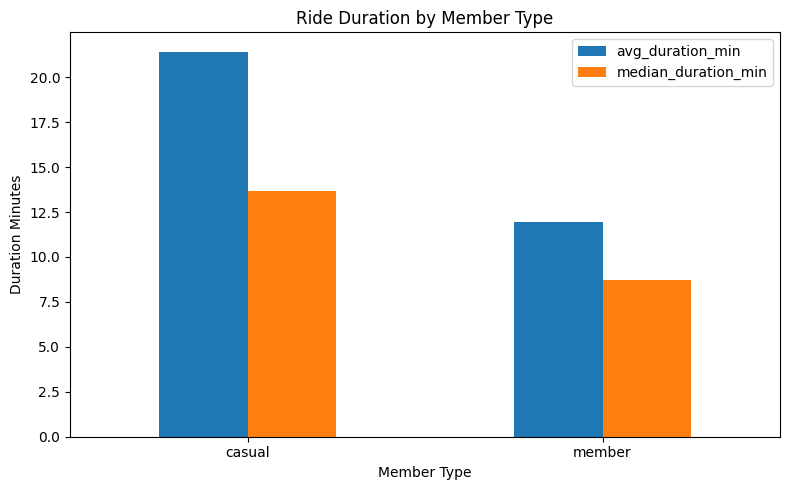

In [5]:
duration_plot_data = duration_by_member[
    ["member_casual", "avg_duration_min", "median_duration_min"]
].set_index("member_casual")

duration_plot_data.plot(kind="bar", figsize=(8, 5))

plt.title("Ride Duration by Member Type")
plt.xlabel("Member Type")
plt.ylabel("Duration Minutes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**观察与总结**

从骑行时长看，临时用户的骑行时长明显高于会员用户。临时用户平均骑行时长约21.42分钟，中位数约13.68分钟；会员平均骑行时长约11.94分钟，中位数约8.71分钟。

从分位数看，临时用户75分位骑行时长约23.69分钟，90分位约39.03分钟；会员75分位约15.06分钟，90分位约23.99分钟。说明临时用户不仅平均时长更长，长时长骑行占比也更高。

这表明会员更可能对应高频、短时长的日常通勤或短途接驳；临时用户则更可能对应休闲、游览或非固定通勤场景。

## 5 对比会员和临时用户的骑行时长分组

平均值和中位数只能概括整体差异，不能展示不同骑行时长区间的结构。本段基于 `duration_group` 对比会员和临时用户在短途、中等时长和长时长骑行中的占比差异。

In [6]:
duration_group_order = [
    "0_5min",
    "5_10min",
    "10_20min",
    "20_30min",
    "30_60min",
    "60min_plus",
]

trip_base["duration_group"] = pd.Categorical(
    trip_base["duration_group"],
    categories=duration_group_order,
    ordered=True,
)

duration_group_by_member = (
    trip_base
    .groupby(["member_casual", "duration_group"], observed=False, as_index=False)
    .agg(rides=("ride_id", "count"))
)

duration_group_by_member["ride_share_within_type"] = (
    duration_group_by_member["rides"]
    / duration_group_by_member.groupby("member_casual")["rides"].transform("sum")
)

display(duration_group_by_member)

,member_casual,duration_group,rides,ride_share_within_type
0,casual,0_5min,107280,0.098459
1,casual,5_10min,272533,0.250125
2,casual,10_20min,359848,0.330260
3,casual,20_30min,171441,0.157345
4,casual,30_60min,130203,0.119497
5,casual,60min_plus,48284,0.044314
6,member,0_5min,896026,0.246747
7,member,5_10min,1164596,0.320706
8,member,10_20min,1027229,0.282878
9,member,20_30min,341257,0.093975


In [7]:
duration_group_pivot = duration_group_by_member.pivot(
    index="duration_group",
    columns="member_casual",
    values="ride_share_within_type",
)

display(duration_group_pivot)

member_casual,casual,member
duration_group,,
0_5min,0.098459,0.246747
5_10min,0.250125,0.320706
10_20min,0.330260,0.282878
20_30min,0.157345,0.093975
30_60min,0.119497,0.050602
60min_plus,0.044314,0.005092


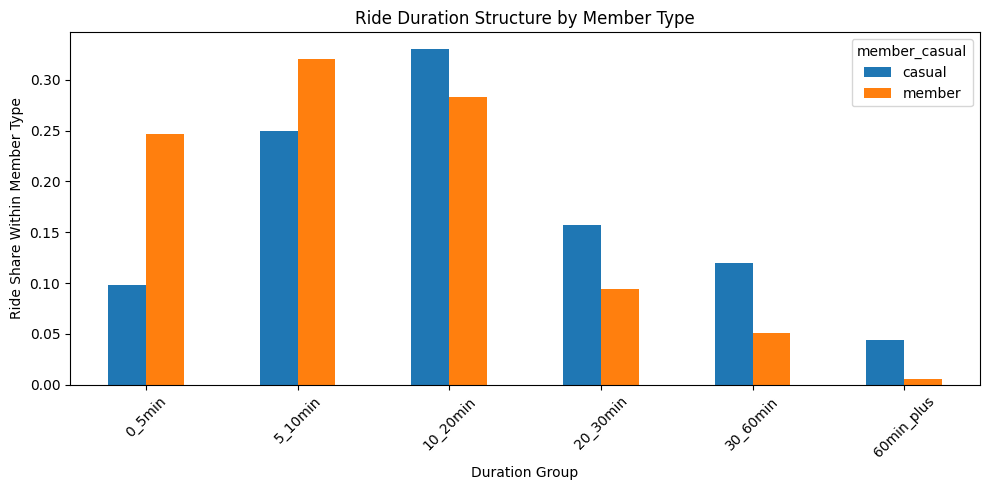

In [8]:
duration_group_pivot.plot(kind="bar", figsize=(10, 5))

plt.title("Ride Duration Structure by Member Type")
plt.xlabel("Duration Group")
plt.ylabel("Ride Share Within Member Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_duration_structure_by_member_type.png", dpi=150, bbox_inches="tight")
plt.show()

**观察与总结**

从骑行时长分组看，会员骑行更集中在短时长区间。会员0到10分钟骑行合计占比约56.75%，其中0到5分钟占比约24.67%，5到10分钟占比约32.07%。

临时用户的骑行时长结构更偏长。临时用户10到20分钟骑行占比最高，约33.03%；20分钟以上骑行合计占比约32.12%，明显高于会员的约14.97%。

进一步看长时长骑行，临时用户30分钟以上骑行占比约16.38%，会员仅约5.57%。这进一步支持了前面的判断：会员更偏短途高频出行，临时用户更偏长时长、休闲或游览型出行。

## 6 对比工作日与周末使用差异

本段比较会员和临时用户在工作日与周末的骑行需求差异。由于工作日和周末天数不同，本段同时计算总骑行次数和日均骑行次数，避免直接比较总量造成偏差。

In [9]:
member_day_type = (
    trip_base
    .groupby(["member_casual", "is_weekend"], as_index=False)
    .agg(
        total_rides=("ride_id", "count"),
        active_days=("start_date", "nunique"),
        avg_duration_min=("ride_duration_min", "mean"),
        median_duration_min=("ride_duration_min", "median"),
    )
)

member_day_type["avg_daily_rides"] = (
    member_day_type["total_rides"] / member_day_type["active_days"]
)

member_day_type["day_type"] = np.where(
    member_day_type["is_weekend"],
    "weekend",
    "weekday",
)

member_day_type = member_day_type[
    [
        "member_casual",
        "day_type",
        "active_days",
        "total_rides",
        "avg_daily_rides",
        "avg_duration_min",
        "median_duration_min",
    ]
]

display(member_day_type)

,member_casual,day_type,active_days,total_rides,avg_daily_rides,avg_duration_min,median_duration_min
0,casual,weekday,23,737788,32077.73913,20.675890,13.028333
1,casual,weekend,8,351801,43975.12500,22.993541,15.149700
2,member,weekday,23,2828672,122985.73913,11.689542,8.577617
3,member,weekend,8,802680,100335.00000,12.838707,9.203958


member_casual,casual,member
day_type,,
weekday,32077.73913,122985.73913
weekend,43975.12500,100335.00000


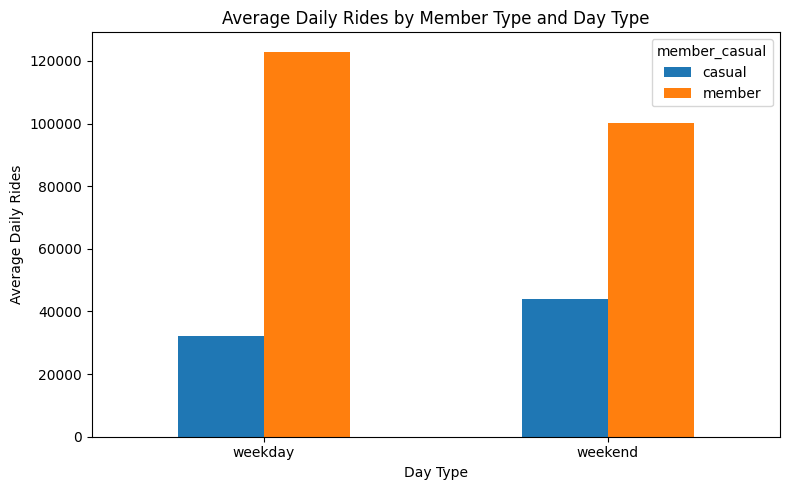

In [10]:
member_day_type_pivot = member_day_type.pivot(
    index="day_type",
    columns="member_casual",
    values="avg_daily_rides",
)

display(member_day_type_pivot)

member_day_type_pivot.plot(kind="bar", figsize=(8, 5))

plt.title("Average Daily Rides by Member Type and Day Type")
plt.xlabel("Day Type")
plt.ylabel("Average Daily Rides")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**观察与总结**

从工作日和周末对比看，会员和临时用户呈现明显不同的日期类型偏好。

会员工作日日均骑行约122986次，周末日均骑行约100335次，说明会员骑行更集中在工作日。这与会员更偏通勤和日常出行的判断一致。

临时用户则相反，工作日日均骑行约32078次，周末日均骑行约43975次，周末日均骑行明显高于工作日。说明临时用户更可能在周末集中使用，使用场景可能更偏休闲、游客或偶发出行。

骑行时长方面，临时用户周末平均骑行约22.99分钟，高于工作日的约20.68分钟；会员周末平均骑行约12.84分钟，也高于工作日的约11.69分钟。说明两类用户在周末的单次骑行时间都更长，但临时用户的周末休闲特征更明显。

## 7 对比会员和临时用户的小时需求曲线

本段按小时对比会员和临时用户的骑行分布。由于会员骑行总量明显高于临时用户，直接比较原始骑行次数会受到规模差异影响。因此，本段重点使用“用户类型内部占比”比较两类用户的一天内需求形态。

In [11]:
hourly_by_member = (
    trip_base
    .groupby(["member_casual", "start_hour"], as_index=False)
    .agg(rides=("ride_id", "count"))
)

hourly_by_member["ride_share_within_type"] = (
    hourly_by_member["rides"]
    / hourly_by_member.groupby("member_casual")["rides"].transform("sum")
)

display(hourly_by_member.head())

,member_casual,start_hour,rides,ride_share_within_type
0,casual,0,23847,0.021886
1,casual,1,15440,0.014170
2,casual,2,10339,0.009489
3,casual,3,6590,0.006048
4,casual,4,5225,0.004795


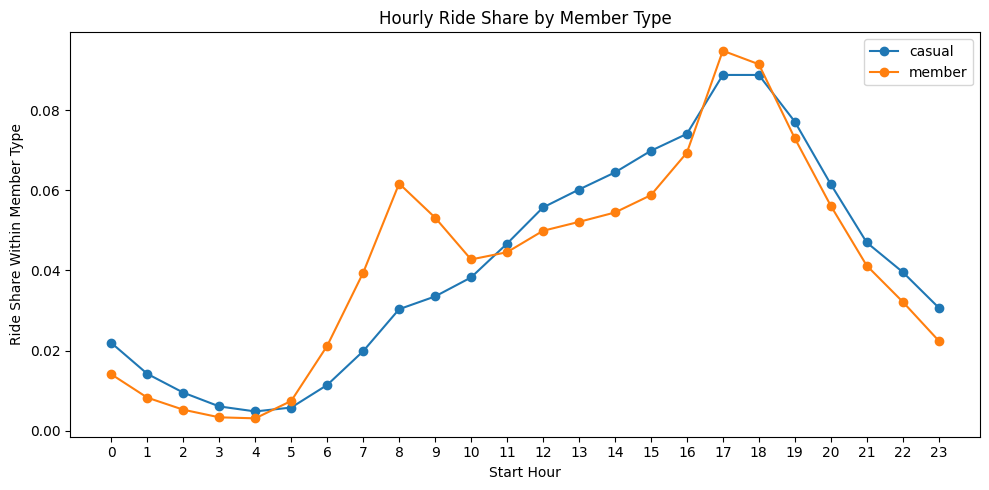

In [12]:
plt.figure(figsize=(10, 5))

for member_type, group_data in hourly_by_member.groupby("member_casual"):
    plt.plot(
        group_data["start_hour"],
        group_data["ride_share_within_type"],
        marker="o",
        label=member_type,
    )

plt.title("Hourly Ride Share by Member Type")
plt.xlabel("Start Hour")
plt.ylabel("Ride Share Within Member Type")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

**观察与总结**

本节使用用户类型内部占比比较小时需求曲线，而不是直接比较原始骑行次数。这样可以避免会员骑行总量明显高于临时用户导致图形被规模差异主导。

从峰值小时看，会员骑行峰值出现在17点，该小时骑行344402次，占会员全部骑行的约9.48%；临时用户峰值出现在18点，该小时骑行96746次，占临时用户全部骑行的约8.88%。

从曲线形态看，会员更明显呈现工作日通勤型特征，早晚高峰更突出；临时用户早高峰相对弱，需求更多集中在下午到晚间。说明两类用户不只是规模不同，使用时间结构也存在差异。

## 8 对比会员和临时用户的时段结构

本段基于 `time_period` 对比会员和临时用户在深夜、早高峰、日间、晚高峰和夜间的骑行结构。相比小时曲线，时段结构更便于总结两类用户的主要使用场景。

In [13]:
time_period_order = [
    "late_night",
    "morning_peak",
    "daytime",
    "evening_peak",
    "night",
]

trip_base["time_period"] = pd.Categorical(
    trip_base["time_period"],
    categories=time_period_order,
    ordered=True,
)

time_period_by_member = (
    trip_base
    .groupby(["member_casual", "time_period"], observed=False, as_index=False)
    .agg(
        rides=("ride_id", "count"),
        avg_duration_min=("ride_duration_min", "mean"),
    )
)

time_period_by_member["ride_share_within_type"] = (
    time_period_by_member["rides"]
    / time_period_by_member.groupby("member_casual")["rides"].transform("sum")
)

display(time_period_by_member)

,member_casual,time_period,rides,avg_duration_min,ride_share_within_type
0,casual,late_night,67729,19.657804,0.062160
1,casual,morning_peak,103575,15.713049,0.095059
2,casual,daytime,365178,22.753997,0.335152
3,casual,evening_peak,358271,22.326424,0.328813
4,casual,night,194836,20.922839,0.178816
5,member,late_night,150080,12.495211,0.041329
6,member,morning_peak,637143,10.831236,0.175456
7,member,daytime,1098553,11.629603,0.302519
8,member,evening_peak,1193563,12.380661,0.328683
9,member,night,552013,12.757113,0.152013


In [14]:
time_period_pivot = time_period_by_member.pivot(
    index="time_period",
    columns="member_casual",
    values="ride_share_within_type",
)

display(time_period_pivot)

member_casual,casual,member
time_period,,
late_night,0.062160,0.041329
morning_peak,0.095059,0.175456
daytime,0.335152,0.302519
evening_peak,0.328813,0.328683
night,0.178816,0.152013


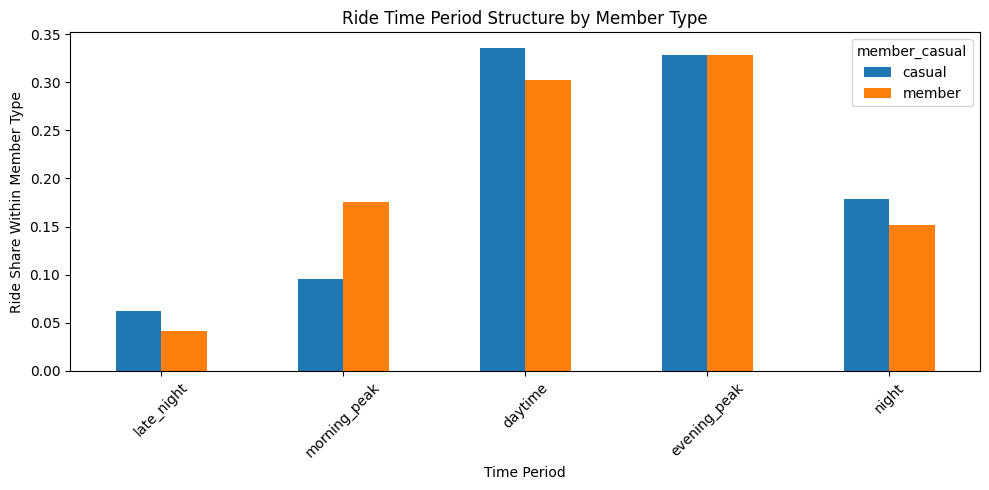

In [15]:
time_period_pivot.plot(kind="bar", figsize=(10, 5))

plt.title("Ride Time Period Structure by Member Type")
plt.xlabel("Time Period")
plt.ylabel("Ride Share Within Member Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**观察与总结**

从时段结构看，会员和临时用户在晚高峰占比几乎相同，均约32.87%，说明晚高峰对两类用户都非常重要。

差异主要体现在早高峰和日间。会员早高峰占比约17.55%，明显高于临时用户的约9.51%，说明会员更具有通勤属性。临时用户日间占比约33.52%，高于会员的约30.25%；夜间和深夜占比也略高于会员，说明临时用户更偏非通勤、休闲或弹性出行场景。

从平均骑行时长看，临时用户在各个时段的平均骑行时长都高于会员。例如日间临时用户平均骑行约22.75分钟，而会员约11.63分钟。这说明临时用户不只是使用时段不同，单次使用深度也更高。

## 9 对比会员和临时用户的车型偏好

本段对比会员和临时用户使用不同车型的占比。车型偏好可以帮助判断两类用户对普通自行车和电动自行车的需求差异，也可以为车辆投放结构提供参考。

In [16]:
bike_type_by_member = (
    trip_base
    .groupby(["member_casual", "rideable_type"], as_index=False)
    .agg(
        rides=("ride_id", "count"),
        avg_duration_min=("ride_duration_min", "mean"),
    )
)

bike_type_by_member["ride_share_within_type"] = (
    bike_type_by_member["rides"]
    / bike_type_by_member.groupby("member_casual")["rides"].transform("sum")
)

display(bike_type_by_member)

,member_casual,rideable_type,rides,avg_duration_min,ride_share_within_type
0,casual,classic_bike,313757,22.623519,0.287959
1,casual,electric_bike,775832,20.939181,0.712041
2,member,classic_bike,1293279,11.378316,0.356143
3,member,electric_bike,2338073,12.256211,0.643857


member_casual,casual,member
rideable_type,,
classic_bike,0.287959,0.356143
electric_bike,0.712041,0.643857


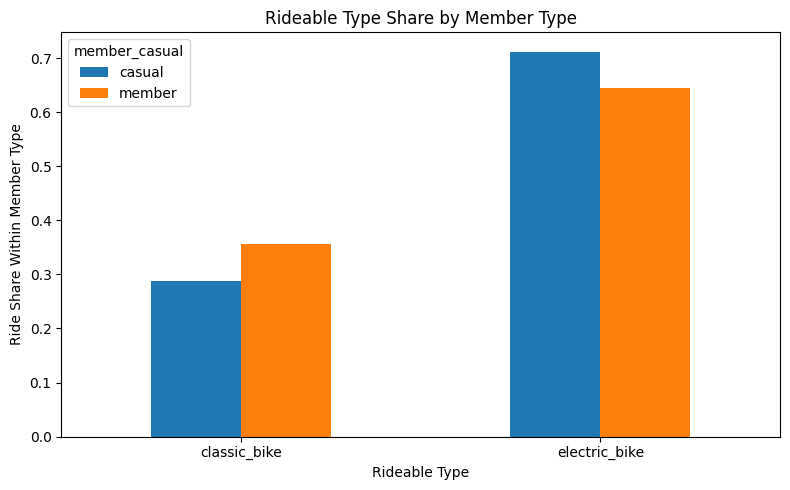

In [17]:
bike_type_pivot = bike_type_by_member.pivot(
    index="rideable_type",
    columns="member_casual",
    values="ride_share_within_type",
)

display(bike_type_pivot)

bike_type_pivot.plot(kind="bar", figsize=(8, 5))

plt.title("Rideable Type Share by Member Type")
plt.xlabel("Rideable Type")
plt.ylabel("Ride Share Within Member Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**观察与总结**

从车型偏好看，电动自行车是两类用户的主要车型。临时用户中，电动自行车占比约71.20%，普通自行车占比约28.80%；会员中，电动自行车占比约64.39%，普通自行车占比约35.61%。

临时用户对电动自行车的依赖更高，可能与其骑行距离更长、骑行目的更偏休闲或游客出行有关。会员虽然也以电动自行车为主，但普通自行车占比相对更高。

从平均骑行时长看，临时用户无论使用普通自行车还是电动自行车，平均骑行时长都明显高于会员。这说明用户类型差异不仅来自车型选择，也来自使用场景本身。

## 10 对比会员和临时用户的Top起点站

本段对比会员和临时用户的高频起点站。由于04中已经确认站点运营分析更适合使用 `station_name` 作为业务站点口径，本段同样基于站点名称统计不同用户类型的起点站分布。

In [18]:
station_member_base = trip_base[trip_base["is_station_sample"]].copy()

station_member_base["start_station_name"] = (
    station_member_base["start_station_name"].str.strip()
)

start_station_by_member = (
    station_member_base
    .groupby(["member_casual", "start_station_name"], as_index=False)
    .agg(
        rides=("ride_id", "count"),
        avg_duration_min=("ride_duration_min", "mean"),
    )
    .rename(columns={"start_station_name": "station_name"})
)

start_station_by_member["rank"] = (
    start_station_by_member
    .groupby("member_casual")["rides"]
    .rank(method="first", ascending=False)
).astype(int)

top_start_station_by_member = (
    start_station_by_member[
        start_station_by_member["rank"] <= 10
    ]
    .sort_values(["member_casual", "rank"])
)

display(top_start_station_by_member)

,member_casual,station_name,rides,avg_duration_min,rank
412,casual,7 Ave & Central Park South,6743,37.681470,1
738,casual,Central Park S & 6 Ave,6615,37.654954,2
2094,casual,West St & Chambers St,5110,22.830887,3
50,casual,12 Ave & W 40 St,4932,24.176350,4
14,casual,10 Ave & W 14 St,4881,25.009445,5
739,casual,Central Park S & Grand Army Plaza,4714,39.743931,6
295,casual,5 Ave & E 72 St,4511,30.181526,7
297,casual,5 Ave & E 87 St,4261,32.690052,8
661,casual,Broadway & W 58 St,4233,33.002966,9
744,casual,Central Park West & W 72 St,4223,33.028696,10


**观察与总结**

从Top起点站看，临时用户和会员的高频起点站存在明显差异。

临时用户Top起点站集中在Central Park及周边区域，例如 `7 Ave & Central Park South`、`Central Park S & 6 Ave`、`Central Park S & Grand Army Plaza`、`5 Ave & E 72 St` 等。这些站点的平均骑行时长普遍较长，很多超过30分钟，说明临时用户高频站点更偏休闲、游览和游客型出行。

会员Top起点站则更多集中在通勤、办公或城市核心活动区域，例如 `W 21 St & 6 Ave`、`University Pl & E 14 St`、`Broadway & E 21 St`、`8 Ave & W 31 St` 等。会员Top站点的平均骑行时长大多在10分钟左右，更接近日常短途出行或通勤接驳。

这说明两类用户不仅在时间和时长上不同，在空间使用场景上也存在差异。后续运营上可以将临时用户高频站点与游客区域、休闲路线和电动自行车供给结合考虑；会员高频站点则更适合结合通勤高峰和车辆可得性进行优化。

## 11 汇总核心指标

本段汇总会员和临时用户差异分析中的关键指标，便于后续 README 和 Power BI 看板引用。

In [19]:
member_key_metrics = (
    trip_base
    .groupby("member_casual", as_index=False)
    .agg(
        rides=("ride_id", "count"),
        avg_duration_min=("ride_duration_min", "mean"),
        median_duration_min=("ride_duration_min", "median"),
        weekend_rides=("is_weekend", "sum"),
    )
)

member_key_metrics["ride_share"] = (
    member_key_metrics["rides"] / member_key_metrics["rides"].sum()
)

member_key_metrics["weekend_ride_share"] = (
    member_key_metrics["weekend_rides"] / member_key_metrics["rides"]
)

display(member_key_metrics)

,member_casual,rides,avg_duration_min,median_duration_min,weekend_rides,ride_share,weekend_ride_share
0,casual,1089589,21.424202,13.68110,351801,0.230799,0.322875
1,member,3631352,11.943555,8.70925,802680,0.769201,0.221042


In [20]:
peak_hour_by_member = (
    hourly_by_member
    .sort_values(["member_casual", "rides"], ascending=[True, False])
    .groupby("member_casual", as_index=False)
    .head(1)
    [
        [
            "member_casual",
            "start_hour",
            "rides",
            "ride_share_within_type",
        ]
    ]
    .rename(
        columns={
            "start_hour": "peak_hour",
            "rides": "peak_hour_rides",
            "ride_share_within_type": "peak_hour_share_within_type",
        }
    )
)

display(peak_hour_by_member)

,member_casual,peak_hour,peak_hour_rides,peak_hour_share_within_type
18,casual,18,96746,0.088791
41,member,17,344402,0.094841


**观察与总结**

核心指标汇总进一步验证了前面各节的判断。会员贡献约76.92%的骑行记录，是本月主要骑行来源；临时用户贡献约23.08%的骑行记录，但平均骑行时长和周末占比更高。

临时用户平均骑行时长约21.42分钟，中位数约13.68分钟，周末骑行占比约32.29%；会员平均骑行时长约11.94分钟，中位数约8.71分钟，周末骑行占比约22.10%。

峰值小时方面，会员峰值在17点，临时用户峰值在18点。会员更偏通勤高峰，临时用户更偏下午到晚间的休闲或弹性出行。

综合来看，会员是高频短途使用主体，临时用户虽然规模较小，但单次骑行更长、周末占比更高、电动自行车占比更高，具有更明显的休闲和游客型出行特征。

## 总结

本 Notebook 基于 `trip_base_202407.csv` 对Citi Bike会员用户和临时用户的骑行行为差异进行了分析。

需要注意的是，本数据不包含真实用户ID，因此无法分析单个用户的留存、复购或生命周期。本 Notebook 中的“会员”和“临时用户”对比，均是基于 `member_casual` 字段对骑行记录进行分组后的行为差异分析，而不是独立用户个体分析。

从骑行规模看，会员骑行记录为3631352次，占全部骑行的约76.92%；临时用户骑行记录为1089589次，占比约23.08%。会员是本月Citi Bike最主要的骑行来源，日均骑行约117140次，明显高于临时用户的约35148次。

从骑行时长看，临时用户单次骑行明显更长。临时用户平均骑行时长约21.42分钟，中位数约13.68分钟；会员平均骑行时长约11.94分钟，中位数约8.71分钟。临时用户30分钟以上骑行占比约16.38%，会员仅约5.57%。这说明会员更偏高频、短途、通勤或日常接驳，临时用户更偏长时长、休闲或游客型出行。

从工作日和周末看，会员更集中在工作日，工作日日均骑行约122986次，高于周末的约100335次。临时用户则更集中在周末，周末日均骑行约43975次，高于工作日的约32078次。两类用户在日期类型上的差异进一步说明，会员更偏日常通勤，临时用户更偏周末休闲和偶发使用。

从小时和时段结构看，会员峰值小时为17点，临时用户峰值小时为18点。两类用户在晚高峰占比都很高，但会员早高峰占比约17.55%，明显高于临时用户的约9.51%；临时用户日间、夜间和深夜占比相对更高。这说明会员需求更具有通勤节奏，临时用户需求更偏弹性出行。

从车型偏好看，电动自行车是两类用户的主要车型，但临时用户对电动自行车的偏好更强。临时用户电动自行车占比约71.20%，会员约64.39%。结合临时用户骑行时长更长的结果，可以推测电动自行车对临时用户的长时长和休闲型出行具有更强吸引力。

从站点使用看，临时用户Top起点站集中在Central Park及周边区域，且平均骑行时长普遍较长，说明临时用户更偏游客、休闲或观光场景。会员Top起点站更多集中在城市核心通勤和办公活动区域，平均骑行时长大多在10分钟左右，更接近日常短途出行。

综合来看，Citi Bike的会员和临时用户对应不同使用场景。会员是高频短途骑行主体，更适合围绕通勤高峰、车辆可得性和核心站点补车进行运营优化；临时用户规模较小但骑行时长更长、周末占比更高、电动自行车占比更高，更适合围绕休闲骑行体验、热门游客区域、电动自行车供给和临时用户转会员策略进行优化。

下一步将在 `06_export_bi_data.ipynb` 中整理 BI 数据表，为 README 展示和 Power BI 看板制作做准备。